In [1]:
import os, sys
%pylab inline
plt.style.use('default')
import pandas as pd
from importlib import reload
spines_off = lambda ax: [ax.spines[side].set_visible(False) for side in ['top', 'right']]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# Google sheet with the data
spreadsheet_id = "1rF6KRdGkyQq3VtTHx7fhZoprIboU4AooWy5Jqx5fbeg"
SHEET_URL = lambda gid: f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={gid}"

In [3]:
proj_path = os.path.join(os.environ["GIT"], "lucia-natural-odour-stats")
sys.path.append(proj_path)

In [4]:
os.chdir(proj_path)
os.getcwd()

'/Users/sinatootoonian/git/lucia-natural-odour-stats'

In [5]:
from lucia_stats import data as lucia_data
reload(lucia_data)
df = lucia_data.get_noni_ripeness(do_zscore=True)

In [6]:
from lucia_stats import sechellia
reload(sechellia)

<module 'lucia_stats.sechellia' from '/Users/sinatootoonian/git/lucia-natural-odour-stats/lucia_stats/sechellia.py'>

In [118]:
reload(lucia_data)
reload(sechellia)
A = sechellia.Analysis()
results = A.fit_models()#results=results)

In [133]:
A.compute_lasso_sparsity()
A.compute_pc_var_overlap()
A.compute_confusion_matrices()
A.compute_p_values(n_rand=1000)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:40<00:00, 24.93it/s]


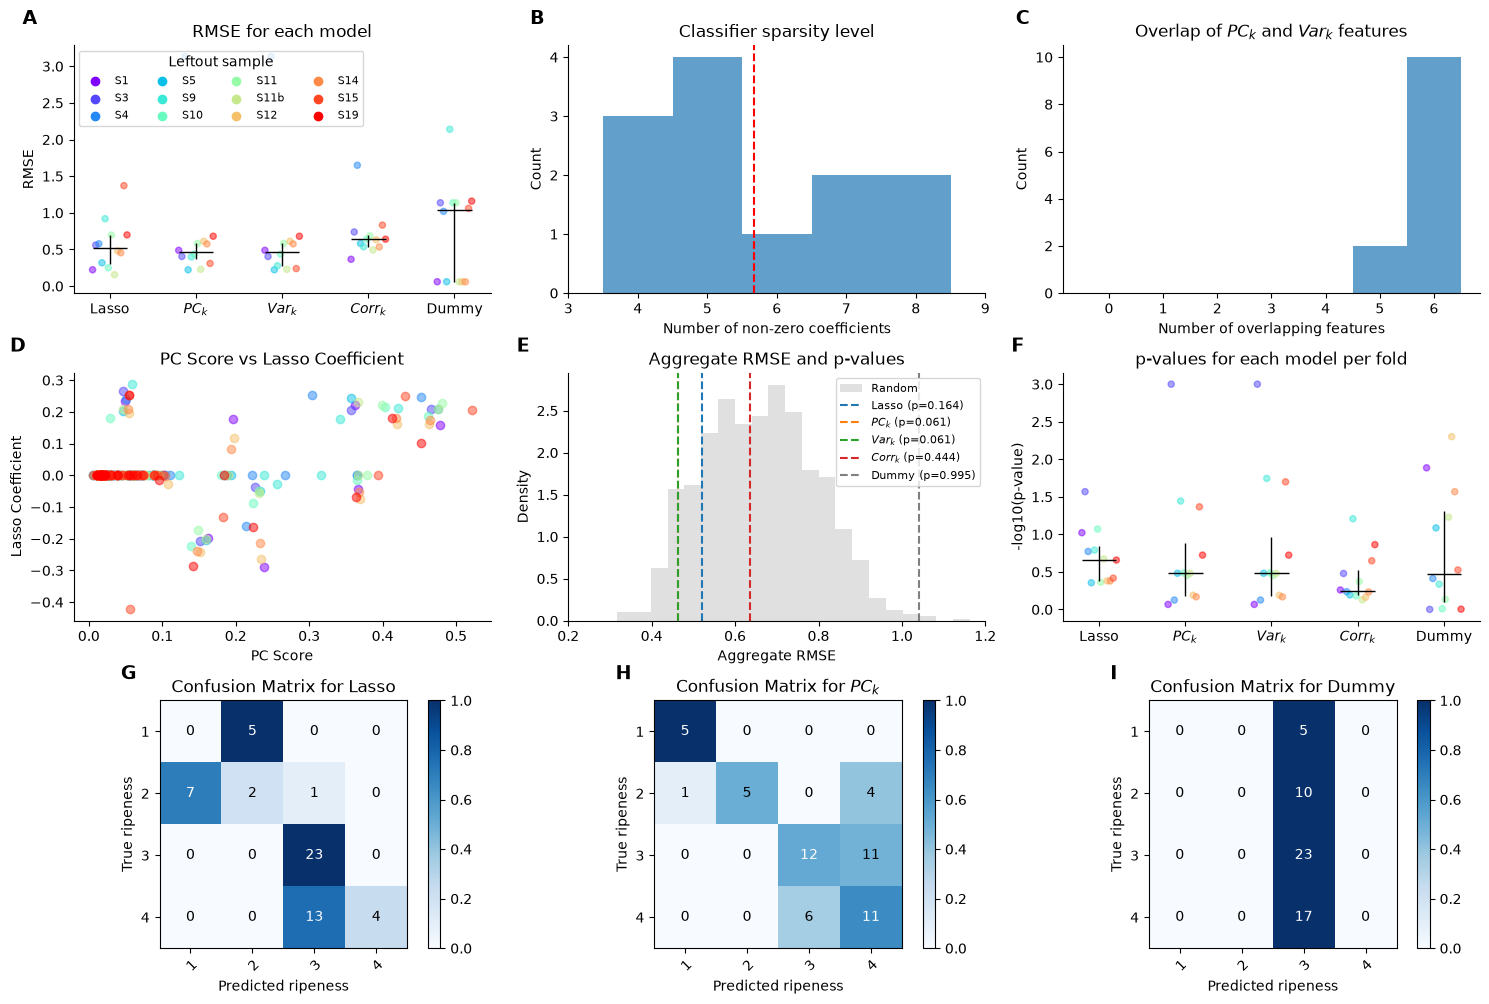

In [135]:
reload(sechellia)
pr = sechellia.PlotResults(A, colorby="fold")
pr.plot_figure()

# Sechellia Analysis

## Load the data

### Load the MS-GC data from its tab.

In [3]:
noni_data_gid = 365555364
noni_url = SHEET_URL(noni_data_gid)
df = pd.read_csv(noni_url)
df = df.set_index('Odour')
column_tuples = [col.split('_rep') for col in df.columns]
df.columns = pd.MultiIndex.from_tuples(column_tuples, names=['Sample', 'Replicate'])
df.head()

Sample                          S1                                      \
Replicate                        1        2        3        4        5   
Odour                                                                    
1-Butanol                    22608    16326    13068    12336        0   
Acetoin                      45918    14022    27243    18343    15871   
3-Buten-1-ol, 3-methyl-    2580259  2158629  2357474  2259012  2103779   
2-Buten-1-ol, 3-methyl-     674520   630612   732131   718104   658692   
Butanoic acid              5874729  4386522  4633598  4017837  4495302   

Sample                         S3                                 ...  \
Replicate                       1       2       3       4      5  ...   
Odour                                                             ...   
1-Butanol                   11260   16062   14231       0      0  ...   
Acetoin                         0   28471   41499   14181      0  ...   
3-Buten-1-ol, 3-methyl-    117524  127602  134611  109834  44000  ...   
2-Buten-1-ol, 3-methyl-         0       0       0       0      0  ...   
Butanoic acid               95230  120797  121843   88793  31346  ...   

Sample                         S14               S15                    \
Replicate                        3        4        1        2        3   
Odour                                                                    
1-Butanol                        0        0        0        0        0   
Acetoin                          0        0        0        0        0   
3-Buten-1-ol, 3-methyl-     667591   848127   893586   829264   517389   
2-Buten-1-ol, 3-methyl-     308326   337044    97781   292570   191330   
Butanoic acid              7626271  4078468  7316017  6817611  3797595   

Sample                                  S19                             
Replicate                        4        1        2        3        4  
Odour                                                                   
1-Butanol                        0        0        0        0        0  
Acetoin                          0    40177    37498    42677    55111  
3-Buten-1-ol, 3-methyl-     573200  2921460  2224380  1637663  2183612  
2-Buten-1-ol, 3-methyl-     224638   516776   390627   335225   390357  
Butanoic acid              5706286  6079282  4845396  3526877  2478420  

[5 rows x 55 columns]

### Get the ripeness data from its tab.

In [4]:
# It's the first row of desc_data_10k... sheet.
dsec_avgs_gid = "522303434"
dsec = pd.read_csv(SHEET_URL(dsec_avgs_gid), header=None)
dsec.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,ripiness,3,3,3,2,4,4,2,3,1,4,4,3,NaN,NaN,NaN,NaN
1,Odour,Avg S1,Avg S3,Avg S4,Avg S5,Avg S9,Avg S10,Avg S11,Avg S11b,Avg S12,Avg S14,Avg S15,Avg S19,NaN,NaN,NaN,NaN
2,1-Butanol,12867.6,8310.6,0,0,274043,6010.75,2792,1297163.8,0,0,0,0,NaN,NaN,NaN,NaN
3,Acetoin,24279.4,16830.2,20225.5,120801.6667,1376256.6,82057,15715.75,397236.4,7297.8,7045,0,43865.75,NaN,NaN,NaN,NaN
4,"3-Buten-1-ol, 3-methyl-",2291830.6,106714.2,66715.25,50344.16667,1331366.8,3495342.75,34384.25,1731697.6,7636,895177.5,703359.75,2241778.75,NaN,NaN,NaN,NaN


In [6]:
mask = dsec.iloc[1].notna() & (dsec.columns != 0) 
cols = dsec.columns[mask]
sample_ids = dsec.iloc[1][cols].str.replace(r'^Avg\s+', '', regex=True).values
ripeness = dsec.iloc[0][cols].values
# Create a dictionary mapping from sample ID to ripeness
sample_ripeness = dict(zip(sample_ids, ripeness))
print(sample_ripeness)

{'S1': '3', 'S3': '3', 'S4': '3', 'S5': '2', 'S9': '4', 'S10': '4', 'S11': '2', 'S11b': '3', 'S12': '1', 'S14': '4', 'S15': '4', 'S19': '3'}


### Rearrange data into rows

In [7]:
tidy = df.T.reset_index()
tidy.columns.name = None
tidy["Ripeness"] = tidy["Sample"].map(sample_ripeness)
# add a "Ripeness" column which inserts the value based using the  
missing = set(tidy['Sample']) - set(sample_ripeness) 
assert not missing, f"No ripeness for: {missing}" 
tidy.insert(2, 'Ripeness', tidy.pop('Ripeness'))
tidy["Replicate"] = tidy["Replicate"].astype(int)
tidy["Ripeness"] = tidy["Ripeness"].astype(int)
tidy.head()

,Sample,Replicate,Ripeness,1-Butanol,Acetoin,"3-Buten-1-ol, 3-methyl-","2-Buten-1-ol, 3-methyl-",Butanoic acid,1-Hexanol,"3-Methyl-3-buten-1-ol, acetate",...,"Propanoic acid, 3-(methylthio)-, pentyl ester","Pyridine, 3-(1-methyl-2-pyrrolidinyl)-, (S)-","2,4(1H,3H)-Pyrimidinedione, 5-amino-",Isobutyl 3-methylbut-3-enyl carbonate,"1H-1,2,4-Triazole-3-carboxaldehyde, 5-methyl-","Octanoic acid, 3-methylbut-2-enyl ester","Benzoic acid, 2,6-dichloro-",Azetidine,"Benzoic acid, pentyl ester",n-Hexadecanoic acid
0,S1,1,3,22608,45918,2580259,674520,5874729,118295,0,...,13791,0,0,29775,0,0,11934,13376,13772,20873
1,S1,2,3,16326,14022,2158629,630612,4386522,96801,0,...,0,0,0,29385,0,0,0,10759,14572,68478
2,S1,3,3,13068,27243,2357474,732131,4633598,129892,0,...,0,0,0,39844,0,0,0,14872,18006,0
3,S1,4,3,12336,18343,2259012,718104,4017837,116736,0,...,0,0,0,34413,0,0,30798,13922,16720,20763
4,S1,5,3,0,15871,2103779,658692,4495302,118369,0,...,0,0,0,34262,0,0,113329,15131,16371,24754


### Z-Score the rows

In [8]:
from scipy.stats import zscore
meta_cols = ["Sample", "Replicate", "Ripeness"]
odour_cols = tidy.columns.difference(meta_cols)
tidy_z = tidy.copy()
tidy_z[odour_cols] = zscore(tidy[odour_cols].values, axis=1, nan_policy='omit')

In [9]:
tidy.head()

,Sample,Replicate,Ripeness,1-Butanol,Acetoin,"3-Buten-1-ol, 3-methyl-","2-Buten-1-ol, 3-methyl-",Butanoic acid,1-Hexanol,"3-Methyl-3-buten-1-ol, acetate",...,"Propanoic acid, 3-(methylthio)-, pentyl ester","Pyridine, 3-(1-methyl-2-pyrrolidinyl)-, (S)-","2,4(1H,3H)-Pyrimidinedione, 5-amino-",Isobutyl 3-methylbut-3-enyl carbonate,"1H-1,2,4-Triazole-3-carboxaldehyde, 5-methyl-","Octanoic acid, 3-methylbut-2-enyl ester","Benzoic acid, 2,6-dichloro-",Azetidine,"Benzoic acid, pentyl ester",n-Hexadecanoic acid
0,S1,1,3,22608,45918,2580259,674520,5874729,118295,0,...,13791,0,0,29775,0,0,11934,13376,13772,20873
1,S1,2,3,16326,14022,2158629,630612,4386522,96801,0,...,0,0,0,29385,0,0,0,10759,14572,68478
2,S1,3,3,13068,27243,2357474,732131,4633598,129892,0,...,0,0,0,39844,0,0,0,14872,18006,0
3,S1,4,3,12336,18343,2259012,718104,4017837,116736,0,...,0,0,0,34413,0,0,30798,13922,16720,20763
4,S1,5,3,0,15871,2103779,658692,4495302,118369,0,...,0,0,0,34262,0,0,113329,15131,16371,24754


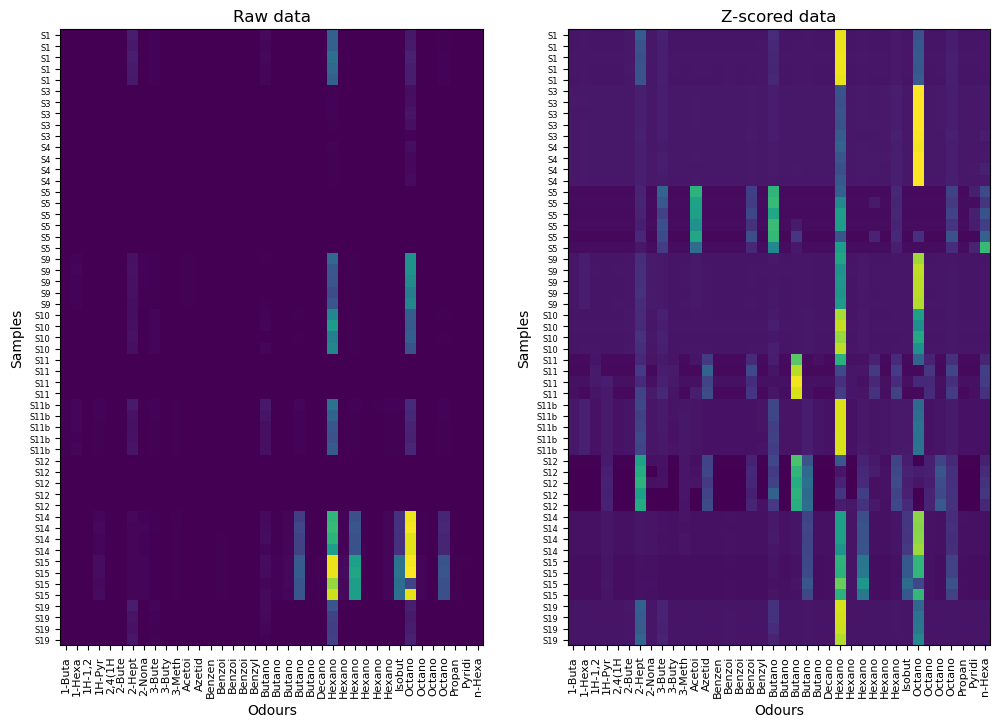

In [10]:
fig, ax = subplots(nrows=1, ncols=2, figsize=(12,8))
ax[0].matshow(tidy[odour_cols], aspect='auto', cmap='viridis'); ax[0].set_title("Raw data"); ax[0].set_xlabel("Odours"); ax[0].set_ylabel("Samples")
ax[1].matshow(tidy_z[odour_cols], aspect='auto', cmap='viridis'); ax[1].set_title("Z-scored data"); ax[1].set_xlabel("Odours"); ax[1].set_ylabel("Samples")
# put the odour ticks on the bottom and label them
for ax_ in ax:
    ax_.set_xticks(range(len(odour_cols)))
    ax_.set_xticklabels([od[:6] for od in odour_cols], rotation=90, fontsize=8)
    # Put the x ticks on the bottom
    ax_.xaxis.set_ticks_position('bottom')
    ax_.set_yticks(range(len(tidy)))
    ax_.set_yticklabels(tidy['Sample'], fontsize=6)

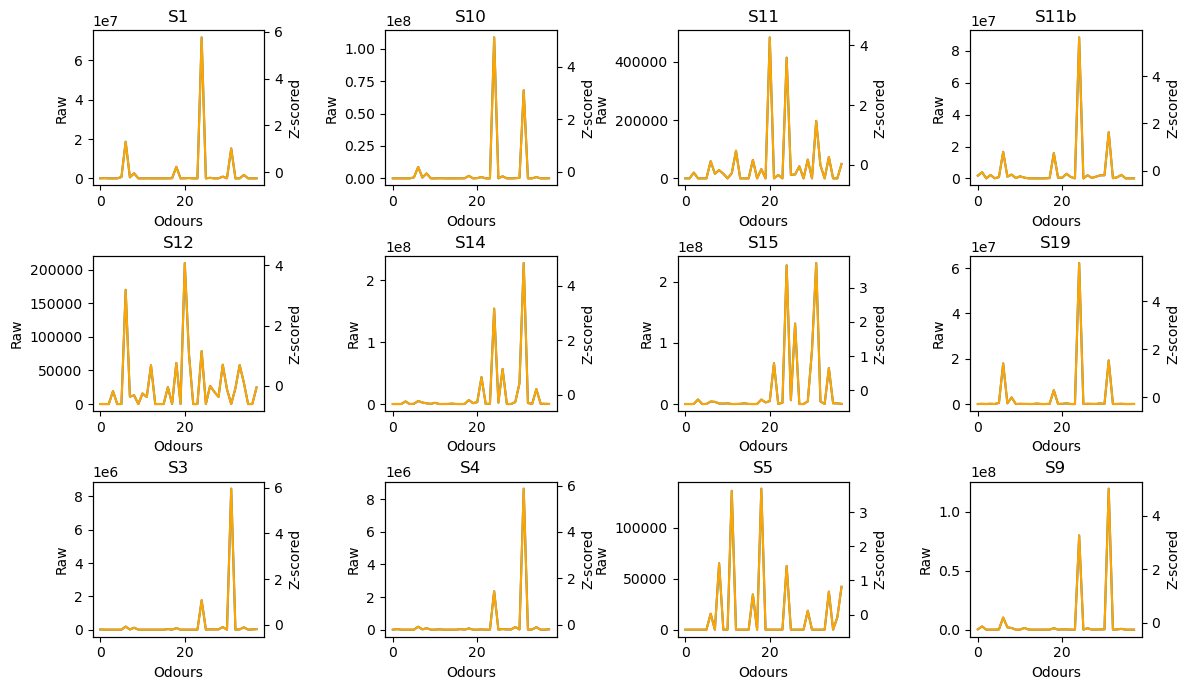

In [11]:
## Let's plot the effects of z-scoring. We'll make a figure consisting of subplots, one for each odour.abs
samples = np.unique(tidy["Sample"].values.astype(str))
n_samp = len(samples) 
fig, ax = subplots(nrows=3,ncols=4, figsize=(12,7),)
for i, samp in enumerate(samples):
    v = tidy[(tidy.Sample==samp) & (tidy.Replicate==1)][odour_cols].values
    z = tidy_z[(tidy_z.Sample==samp) & (tidy_z.Replicate==1)][odour_cols].values
    r, c = i//4, i%4
    ax[r,c].plot(v.flatten(), label='Raw')
    axi = twinx(ax[r,c])
    axi.plot(z.flatten(), label='Z-scored', color='orange')
    ax[r,c].set_title(samp)
    ax[r,c].set_ylabel("Raw")
    axi.set_ylabel("Z-scored")
    ax[r,c].set_xlabel("Odours")
plt.tight_layout(w_pad=0, h_pad=0.5)




## PCA

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)

scores = pca.fit_transform(tidy_z[odour_cols].values)
tidy_z[['PC1', 'PC2', 'PC3']] = scores
ev = pca.explained_variance_ratio_
pcs= pca.components_

### Compute PC scores

In [13]:
# Compute the PC score of each odour
pc_score = np.sum(diag(ev) @ abs(pcs[:3]), axis=0) # Multiply the absolute loadings by the variance explained, then sum across the first 3 PCs

### Plot the PCs, and the PC scores for each odour

[[None, None], [None, None], [None, None], [None, None]]

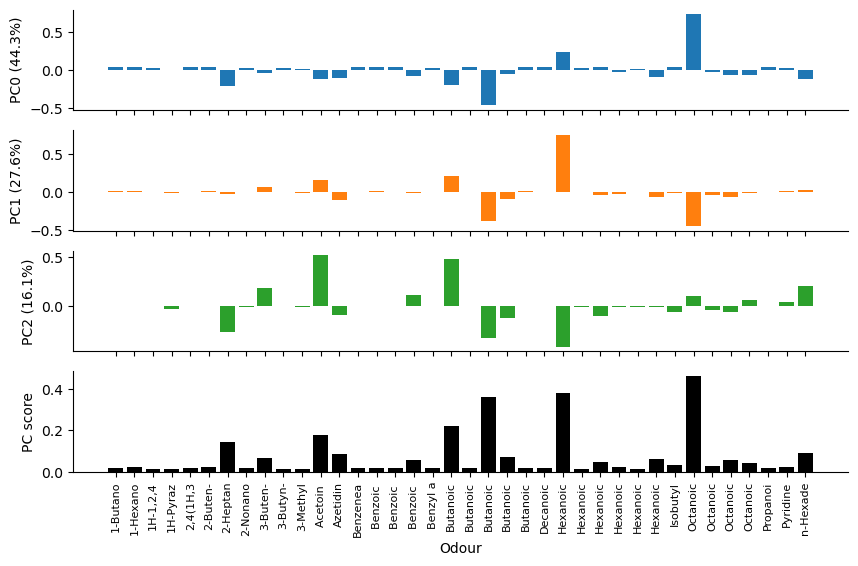

In [14]:
# Plot the principal components
fig,ax = subplots(nrows=4,ncols=1, figsize=(10,6))
for i, (axi, pc, ev) in enumerate(zip(ax, pca.components_, pca.explained_variance_ratio_)):
    axi.set_xticks(range(len(odour_cols)))
    # Do a bar graph 
    axi.bar(range(len(odour_cols)), pc, label=f'PC{i}', color=f"C{i}")
    axi.set_ylabel(f'PC{i} ({ev:.1%})') 
    axi.set_xticklabels([])
ax[-1].bar(range(len(odour_cols)), pc_score, label='PC score', color="black")
ax[-1].set_xticks(range(len(odour_cols)))
ax[-1].set_xticklabels([od[:8] for od in odour_cols], rotation=90, fontsize=8);
ax[-1].set_ylabel('PC score')
ax[-1].set_xlabel("Odour")
[spines_off(axi) for axi in ax]

## Classification

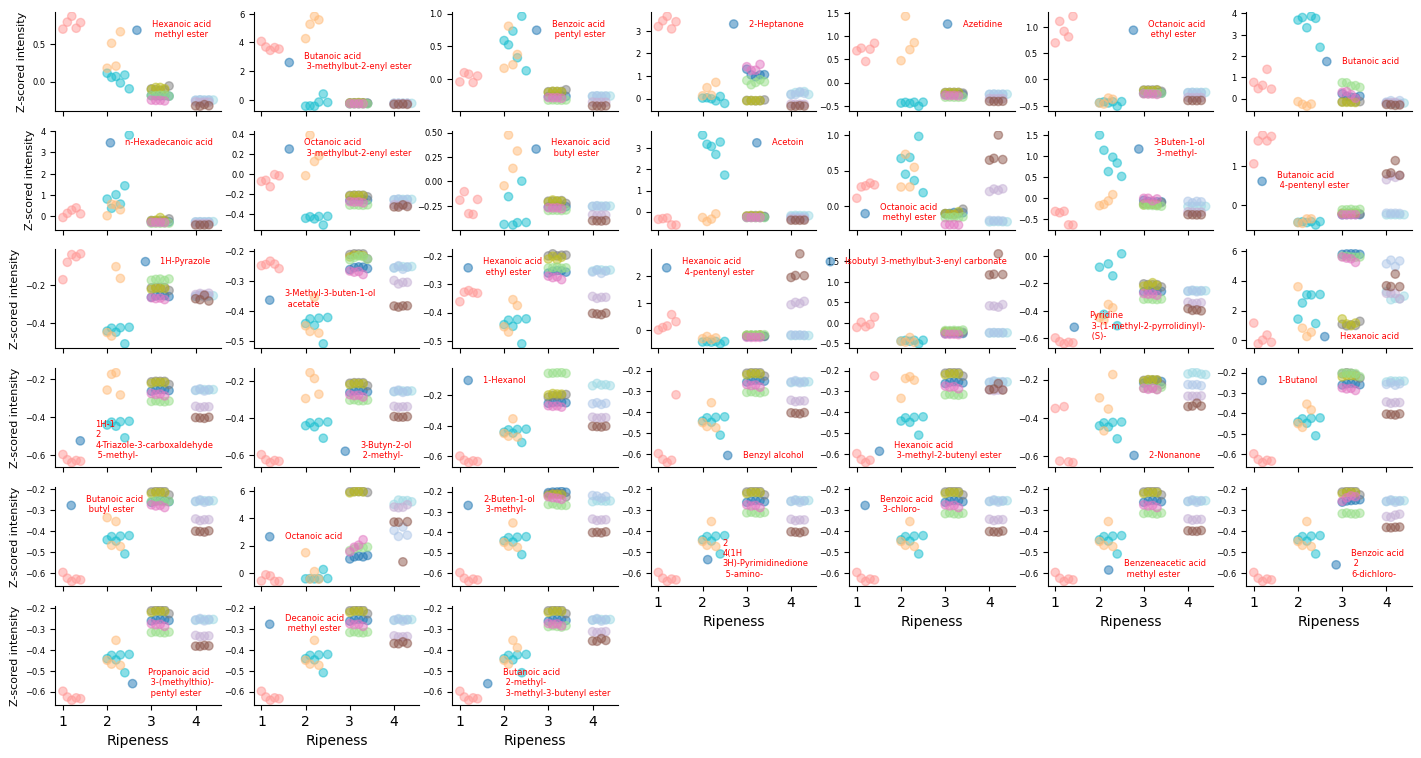

In [15]:
from scipy.stats import spearmanr, pearsonr

# First, let's see how each z-scored odour correlates with ripeness
# Make a square figure full of subplots, each subplot is a scatter plot of one odour vs ripeness
odour_cols = tidy_z.columns.difference(meta_cols)
# Remoev the cols that are PCs
odour_cols = odour_cols[~odour_cols.str.startswith("PC")]

# Compute the pearson correlatio of each odour with ripeness
z_scores = tidy_z[odour_cols].values
y = tidy_z['Ripeness'].values.astype(float)
replicate = tidy_z["Replicate"].values.astype(float)-1
corrs = []
for i in range(z_scores.shape[1]):
    z = z_scores[:, i]
    # Compute the pearson correlation, ignoring NaNs
    r, p = pearsonr(y, z)
    corrs.append(r)
#corrs = np.array([pearsonr(tidy_z['Ripeness'], z_scores[:, i])[0] for i in range(z_scores.shape[1])])

odour_ord = odour_cols[np.argsort(corrs)]

n_rows = 6
n_cols = int(ceil(len(odour_cols) / n_rows))
fig, ax = subplots(nrows=n_rows, ncols=n_cols, figsize=(2.5*n_cols,1.5*n_rows))
codes = pd.Categorical(tidy_z['Sample']).codes
colours = plt.cm.tab20(codes / codes.max())
for i in range(len(odour_cols)):
    odour = odour_ord[i]
    r, c = i//n_cols, i%n_cols
    axi = ax[r, c]
    axi.scatter(y + replicate/10, tidy_z[odour], alpha=0.5, c=colours, label=odour.replace(",", "\n"))
    axi.legend(fontsize=6, frameon=False, labelcolor="red")
    do_xlabs = ((r+1) * n_cols + c >= len(odour_cols)) # Only put x labels on the bottom row
    do_xlabs and axi.set_xlabel("Ripeness")
    not do_xlabs and axi.set_xticklabels([])
    c == 0 and axi.set_ylabel("Z-scored intensity", fontsize=8) 
    axi.set_xticks(arange(1,5))
    #c != 0 and axi.set_yticklabels([])
    spines_off(axi)
    axi.tick_params(axis='y', labelsize=6)

for i in range(len(odour_cols), n_rows*n_cols):
    fig.delaxes(ax.flatten()[i])

# Run a linear classifier

In [16]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import KFold, GroupKFold, cross_val_score, cross_val_predict, cross_validate, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
import warnings

warnings.filterwarnings('ignore')

X = tidy_z[odour_cols]
#X = tidy_z[[odour_ord[-1]]]
print(f"Best odour: {odour_ord[-1]} with r={corrs[np.argmax(corrs)]:.3f}")
y = tidy_z['Ripeness'].astype(float)
groups = tidy_z['Sample']

model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, max_iter=50000, n_alphas=50))
]
)
model.set_params(scaler="passthrough") # Don't standardize, since the data is already z-scored

# What you'd report in a paper
splits_logo = list(LeaveOneGroupOut().split(X, y, groups=groups))
unique_groups = np.unique(groups)
splits_kfold= list(KFold(n_splits=len(unique_groups), shuffle=True, random_state=0).split(X, y))
results = {name:split for name, split in [("logo", splits_logo), ("kfold", splits_kfold)]}
for name, split in [("logo", splits_logo), ("kfold", splits_kfold)]:
    cv_out = cross_validate(
        model,
        X, y,
        cv=split,
        scoring='neg_mean_squared_error',
        return_estimator=True
    )
    results[name] = {"split": split, "results": cv_out}
    results[name]["rmse"] = results[name]["results"]['test_score']
    results[name]["coefs"] = np.array([est.named_steps['lasso'].coef_ for est in results[name]["results"]['estimator']])    
    print(f"RMSE ({name}): {-results[name]['rmse'].mean():.3f} ± {results[name]['rmse'].std():.3f}")

Best odour: Butanoic acid, 2-methyl-, 3-methyl-3-butenyl ester with r=0.765
RMSE (logo): 0.419 ± 0.495
RMSE (kfold): 0.108 ± 0.059


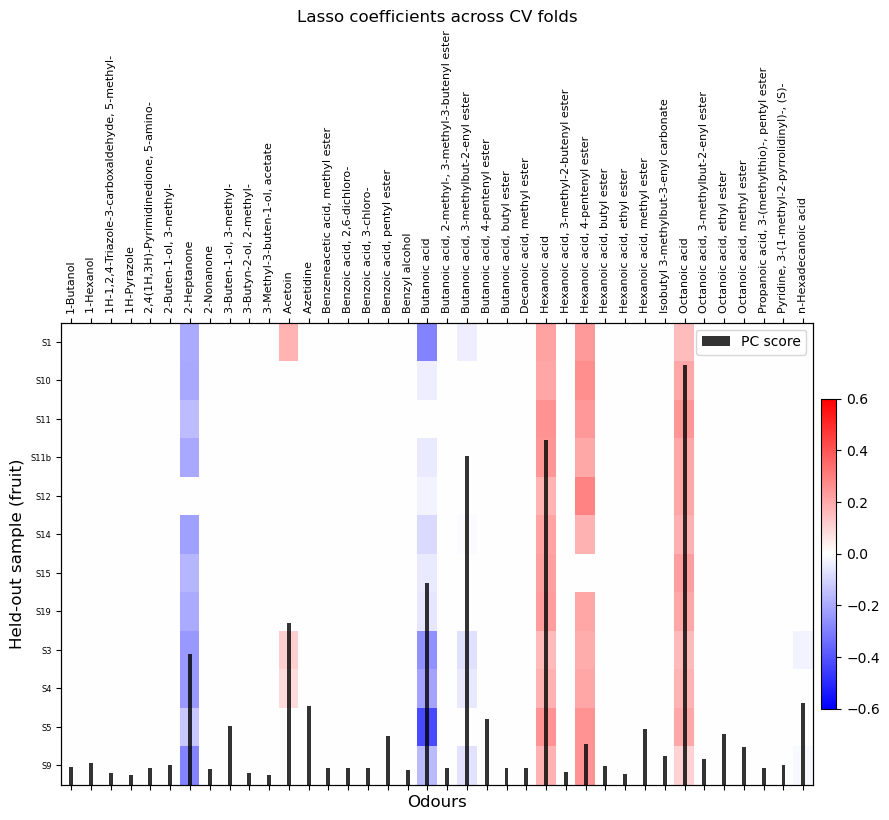

In [17]:
figure(figsize=(10,6))
ax = subplot(4,1,(1,4))
im = ax.matshow(results["logo"]["coefs"], aspect='auto', cmap='bwr', vmin=-0.6, vmax=0.6); 
# Add a colorbar with ticks at -0.6, 0, and 0.6, and label them "Negative", "Zero", "Positive"
cbar = colorbar(im, ax=ax, fraction=0.02, pad=0.01)
xlabel("Odours", fontsize=12); title("Lasso coefficients across CV folds");
ax.set_xticks(range(len(odour_cols)))
ax.set_xticklabels(odour_cols, rotation=90, fontsize=8);
# The yticks are the folds, label them by the held-out sample
ax.set_yticks(range(len(results["logo"]["split"])))
ax.set_yticklabels([groups[test[1][0]] for test in results["logo"]["split"]], fontsize=6)
ax.set_ylabel("Held-out sample (fruit)", fontsize=12)
# Plot the PcA score of each odour as a bar graph above the heatmap
ax2 = ax.twinx()
ax2.bar(range(len(odour_cols)), pc_score, color='black', alpha=0.8, label='PC score', width=0.2)
ax2.set_ylim(0, pc_score.max()*1.1)
#ax2.set_yticks([0, pc_score.max()/2, pc_score.max()])
ax2.set_yticks([])
#ax2.set_yticklabels([0, f"{pc_score.max()/2:.2f}", f"{pc_score.max():.2f}"], fontsize=8)
#ax2.set_ylabel("PCA score", fontsize=12)
ax2.legend(loc='upper right')

In [18]:
y_pred = cross_val_predict(
    model,
    X, y,
    groups=groups,
    cv=results["logo"]["split"],
)
pred_df = pd.DataFrame({
    'Sample': groups,
    'true': y,
    'pred': y_pred,
    'error': y_pred - y,
})
print(pred_df.head())

  Sample  true      pred     error
0     S1   3.0  3.107858  0.107858
1     S1   3.0  3.225689  0.225689
2     S1   3.0  3.267452  0.267452
3     S1   3.0  3.245758  0.245758
4     S1   3.0  3.231961  0.231961


In [19]:
per_fruit = pred_df.groupby('Sample').agg(
    true=('true', 'first'),
    pred_mean=('pred', 'mean'),
    pred_std=('pred', 'std'),
    abs_error=('error', lambda e: e.abs().mean()),
).sort_values('true')
print(per_fruit)

        true  pred_mean  pred_std  abs_error
Sample                                      
S12      1.0   1.918560  0.064142   0.918560
S11      2.0   1.811841  0.630971   0.564971
S5       2.0   0.673040  0.376865   1.326960
S11b     3.0   3.317557  0.029865   0.317557
S19      3.0   3.149478  0.050199   0.149478
S4       3.0   3.453536  0.029117   0.453536
S3       3.0   3.480077  0.007636   0.480077
S1       3.0   3.215743  0.062402   0.215743
S15      4.0   3.335070  0.242908   0.664930
S14      4.0   3.749667  0.011716   0.250333
S10      4.0   3.440634  0.025543   0.559366
S9       4.0   3.301915  0.037124   0.698085


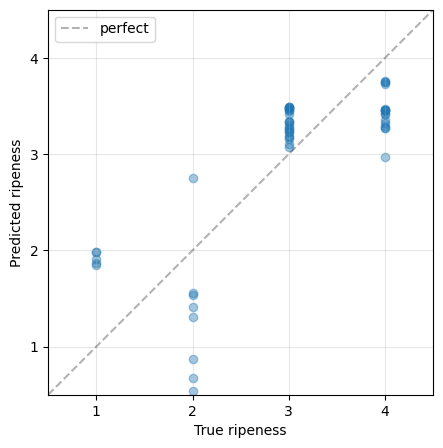

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y, y_pred, alpha=0.4)
lims = [y.min() - 0.5, y.max() + 0.5]
ax.plot(lims, lims, 'k--', alpha=0.3, label='perfect')
# Set the x and y ticks at 1 - 4 and put a grid
ax.set_xticks(range(1,5))
ax.set_yticks(range(1,5))
ax.grid(True, alpha=0.3)
ax.set_xlabel('True ripeness')
ax.set_ylabel('Predicted ripeness')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend()

In [21]:
# Convert the predicted scores to the nearest integer between 1 and 4 and compute the accuracy
y_pred_rounded = np.clip(np.round(y_pred), 1, 4)
accuracy = (y_pred_rounded == y).mean()
print(f"Accuracy (rounded predictions): {accuracy:.2%}")

Accuracy (rounded predictions): 52.73%


# Classification using top PC odours vs random odours.
Next we want to see if the PC odours are informative. Our general approach will be to compare classification performance for three scenarios:
1. Using all odours (as above). Because it's Lasso, it will also provide a sparsity.
2. Using the top PC odours at that level of sparsity.
3. Using the top Variance odours as that level of sparsity
4. Using the most correlated odours at that level of sparsity
5. Using a random set of the remaining odours at that level of sparsity.
6. Using a dummy regressor that just reports the mean training set ripeness.

We'll set the sparsity level to a fixed value of 6, seems like a good number from the above.

We'll do this using nested cross-validation:
We'll pick one sample as validation, another as test, and the rest as training.
We'll fit lasso on the training set to predict ripeness, optimize regularizer on the test set.
We'll compute the PC scores on the training set and take the top according to this level of sparsity.
We'll compute the accuracy of OLS using that set, on the training, test and validation
We'll pick ten random subsets of the same sparsity of the remaining odours.
Compute accuracy for those on the training, test and validation.

We'll report the validation accuracy of the three models.


In [22]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectorMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.decomposition import PCA

class VarianceSelector(SelectorMixin, BaseEstimator):
    def __init__(self, k=10):
        self.k = k
    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns
        X = check_array(X)
        self.n_features_in_ = X.shape[1]

        variances = X.var(axis=0)
        order = np.argsort(variances)[::-1]
        mask = np.zeros(self.n_features_in_, dtype=bool)
        mask[order[:self.k]] = True

        self.variances_ = variances
        self.support_mask_ = mask
        return self
    def _get_support_mask(self):
        check_is_fitted(self, 'support_mask_')
        return self.support_mask_

class PCScoreSelector(SelectorMixin, BaseEstimator):
    def __init__(self, k=10):
        self.k = k
    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns
        X = check_array(X)
        self.n_features_in_ = X.shape[1]
        pca = PCA(n_components=3)
        pca.fit(X)
        ev = pca.explained_variance_ratio_
        pcs= pca.components_
        pc_score = np.sum(np.diag(ev) @ np.abs(pcs[:3]), axis=0) # Multiply the absolute loadings by the variance explained, then sum across the first 3 PCs
        order = np.argsort(pc_score)[::-1]
        mask = np.zeros(self.n_features_in_, dtype=bool)
        mask[order[:self.k]] = True

        self.pc_score_ = pc_score
        self.support_mask_ = mask
        return self
    def _get_support_mask(self):
        check_is_fitted(self, 'support_mask_')
        return self.support_mask_

class RandomSelector(SelectorMixin, BaseEstimator):
    def __init__(self, k=10, random_state=None):
        self.k = k
        self.random_state = random_state
    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns
        X = check_array(X)
        self.n_features_in_ = X.shape[1]
        
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(self.n_features_in_, size=self.k, replace=False)
        mask = np.zeros(self.n_features_in_, dtype=bool)
        mask[idx] = True

        self.random_order_ = idx    
        self.support_mask_ = mask
        return self
    def _get_support_mask(self):
        check_is_fitted(self, 'support_mask_')
        return self.support_mask_

class RandomNonPCSelector(SelectorMixin, BaseEstimator):
    def __init__(self, k=10, random_state=None):
        self.k = k
        self.random_state = random_state
    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns
        X = check_array(X)
        self.n_features_in_ = X.shape[1]
        pca = PCA(n_components=3)
        pca.fit(X)
        ev = pca.explained_variance_ratio_
        pcs= pca.components_
        pc_score = np.sum(np.diag(ev) @ np.abs(pcs[:3]), axis=0) # Multiply the absolute loadings by the variance explained, then sum across the first 3 PCs
        non_pc_idx = np.argsort(pc_score)[:self.n_features_in_-self.k] # Get the indices of the features with the lowest PC scores
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(non_pc_idx, size=self.k, replace=False) # Randomly select k features from the non-PC set
        mask = np.zeros(self.n_features_in_, dtype=bool)
        mask[idx] = True

        self.random_non_pc_order_ = idx    
        self.support_mask_ = mask
        return self
    def _get_support_mask(self):
        check_is_fitted(self, 'support_mask_')
        return self.support_mask_


In [33]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
# Import SelectKBest and f_regression for feature selection
from sklearn.feature_selection import SelectKBest, f_regression
# Import DummyRegressor for a baseline model
from sklearn.dummy import DummyRegressor
# Import make_pipeline for creating pipelines
from sklearn.pipeline import make_pipeline
# Import cross_val_score for evaluating models
from sklearn.model_selection import cross_val_score
# Turn off deprecation warnings from sklearn
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

k = 6
cv = LeaveOneGroupOut()
alphas = np.logspace(-3, 3, 10)
models = {
    "all_lasso": make_pipeline(LassoCV(cv=5, max_iter=50000, n_alphas=50)),
    "pc_k": make_pipeline(PCScoreSelector(k), LinearRegression()),
    "var_k": make_pipeline(VarianceSelector(k), LinearRegression()),
    "corr_k": make_pipeline(SelectKBest(f_regression, k=k), StandardScaler(), RidgeCV(alphas=alphas)),
    "dummy": make_pipeline(DummyRegressor(strategy='median'))
}
X = tidy_z[odour_cols]
y = tidy_z['Ripeness'].astype(float)
groups = tidy_z['Sample']
rmse = {name: -cross_val_score(model, X, y, cv=cv, groups=groups, scoring='neg_root_mean_squared_error') for name, model in models.items()}
rmse_df = pd.DataFrame(rmse)

In [24]:
from tqdm import tqdm
B = 1000
rand_rmse = np.array([
    -cross_val_score(
        make_pipeline(RandomSelector(k, random_state=seed), LinearRegression()),
        X, y, cv=cv, groups=groups, scoring='neg_root_mean_squared_error'   
    )
        for seed in tqdm(range(B))

])

100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [01:08<00:00, 14.64it/s]


In [25]:
B = 1000
rand_nopc_rmse = np.array([
    -cross_val_score(
        make_pipeline(RandomNonPCSelector(k, random_state=seed), LinearRegression()),
        X, y, cv=cv, groups=groups, scoring='neg_root_mean_squared_error'   
    )
        for seed in tqdm(range(B))

])

100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [01:13<00:00, 13.68it/s]


In [34]:
stat = lambda m: np.median(m, axis=-1)

null_stats = stat(rand_nopc_rmse)
for name in models.keys():
    model_stat = stat(rmse[name])
    p_value = (null_stats <= model_stat).mean()
    print(f"{name:>12s}: RMSE={model_stat:.3f}, p-value={p_value:.3f}")

   all_lasso: RMSE=0.520, p-value=0.163
        pc_k: RMSE=0.462, p-value=0.060
       var_k: RMSE=0.462, p-value=0.060
      corr_k: RMSE=0.643, p-value=0.465
       dummy: RMSE=1.000, p-value=0.992


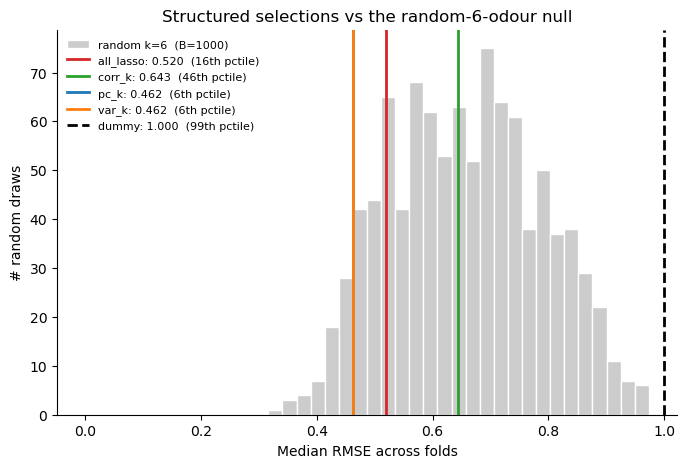

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

  # null distribution: one summary stat per random draw
xmax = np.percentile(null_stats, 99)          # clip the long right tail for readability
ax.hist(null_stats, bins=40, range=(0, xmax),
          color='0.8', edgecolor='white', label=f'random k={k}  (B={B})')
# overlay the structured selections (bookend with dummy + all_lasso for context)
overlays = ["all_lasso", "corr_k", "pc_k", "var_k", "dummy"]
colors   = {"all_lasso":"C3", "corr_k":"C2", "pc_k":"C0", "var_k":"C1", "dummy":"k"}
for name in overlays:
    obs = stat(rmse[name]) 
    pct = 100 * np.mean(null_stats <= obs)
    ax.axvline(obs, color=colors[name], lw=2, ls='--' if name in ("dummy") else '-',
                 label=f'{name}: {obs:.3f}  ({pct:.0f}th pctile)')


ax.set_xlabel('Median RMSE across folds')
ax.set_ylabel('# random draws')
ax.set_title(f'Structured selections vs the random-{k}-odour null')
ax.legend(fontsize=8, frameon=False)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)


# Run the same analysis using the python files